In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os
import plotly.graph_objects as go

from tqdm import tqdm

root = os.path.join('/home/mmccraw/dev/data/26-01-01/grant/friction-surface-thomson')
p_rad = 0.5

def load_scalar_data(root, n_steps, nv):
    mu_mean = []
    mu_std = []
    mu_max = []
    a_rad = []
    path = os.path.join(root, f'{n_steps}', f'{nv}')
    for dir_name in tqdm(os.listdir(path)):
        for f_name in os.listdir(os.path.join(path, dir_name)):
            _, _, _, _a_rad, _, _, _, _ = f_name.split('-')
            _a_rad = float(_a_rad)
            data = np.load(os.path.join(path, dir_name, f_name))
            _mu = data['mu']
            mu_mean.append(np.mean(_mu))
            mu_std.append(np.std(_mu))
            mu_max.append(np.max(_mu))
            a_rad.append(_a_rad)
    return {
        'mu_mean': np.array(mu_mean),
        'mu_max': np.array(mu_max),
        'mu_std': np.array(mu_std),
        'a_rad': np.array(a_rad)
    }

data_0_20 = load_scalar_data(root, 0, 20)
data_0_50 = load_scalar_data(root, 0, 50)

data_100_20 = load_scalar_data(root, 100, 20)
data_100_50 = load_scalar_data(root, 100, 50)

data_10000_20 = load_scalar_data(root, 10000, 20)
data_10000_50 = load_scalar_data(root, 10000, 50)

100%|██████████| 200/200 [00:22<00:00,  9.00it/s]


In [ ]:
def get_avg_edge_length_ico(nv, asperity_radius):
    import numpy as np
    import meshzoo
    import trimesh
    particle_radius = 0.5
    core_radius = particle_radius - asperity_radius
    n_ico = np.maximum(np.round(np.sqrt((nv - 2) / 10)), 1)
    pts, tri = meshzoo.icosa_sphere(int(n_ico))
    pts = np.asarray(pts, dtype=float) * core_radius
    tri = np.asarray(tri, dtype=int)
    m = trimesh.Trimesh(vertices=pts, faces=tri, process=False)
    edge_lengths = np.linalg.norm(np.diff(m.vertices[m.edges], axis=1).squeeze(), axis=-1)
    return np.mean(edge_lengths)

def get_avg_edge_length_thomson(nv, asperity_radius, N_steps):
    import numpy as np
    import meshzoo
    import trimesh
    particle_radius = 0.5
    core_radius = particle_radius - asperity_radius
    import jax
    import jax.numpy as jnp
    from calculate_surface_friction_thomson_particles import random_points_on_sphere, minimize_on_sphere
    from scipy.spatial import ConvexHull
    key = jax.random.PRNGKey(np.random.randint(0, 1e9))
    asperity_pos_init = random_points_on_sphere(key, N=nv)
    if N_steps > 0:
        asperity_pos, _ = minimize_on_sphere(
            asperity_pos_init, alpha=1, lr=0.01 / nv, steps=N_steps
        )
    else:
        asperity_pos = asperity_pos_init

    asperity_pos = asperity_pos * core_radius
    hull = ConvexHull(asperity_pos)
    faces = hull.simplices
    all_edges = np.concatenate([
        faces[:, [0, 1]],
        faces[:, [1, 2]],
        faces[:, [2, 0]],
    ], axis=0)
    all_edges = np.sort(all_edges, axis=1)
    edges = np.unique(all_edges, axis=0)
    edge_lengths = np.linalg.norm(np.diff(asperity_pos[edges], axis=1).squeeze(), axis=-1)
    return np.mean(edge_lengths)

edge_length_thomson_0_20 = np.array([get_avg_edge_length_thomson(20, a_rad, 0) for a_rad in tqdm(np.unique(data_0_20['a_rad']))])
edge_length_thomson_100_20 = np.array([get_avg_edge_length_thomson(20, a_rad, 100) for a_rad in tqdm(np.unique(data_100_20['a_rad']))])
edge_length_thomson_10000_20 = np.array([get_avg_edge_length_thomson(20, a_rad, 10000) for a_rad in tqdm(np.unique(data_10000_20['a_rad']))])

100%|██████████| 100/100 [00:40<00:00,  2.47it/s]


In [51]:
edge_length_thomson_0_50 = np.array([get_avg_edge_length_thomson(50, a_rad, 0) for a_rad in tqdm(np.unique(data_0_50['a_rad']))])
edge_length_thomson_100_50 = np.array([get_avg_edge_length_thomson(50, a_rad, 100) for a_rad in tqdm(np.unique(data_100_50['a_rad']))])
edge_length_thomson_10000_50 = np.array([get_avg_edge_length_thomson(50, a_rad, 10000) for a_rad in tqdm(np.unique(data_10000_50['a_rad']))])

100%|██████████| 100/100 [00:41<00:00,  2.41it/s]


In [108]:
def get_thomson_energy(nv, N_steps):
    import numpy as np
    import jax
    import jax.numpy as jnp
    from calculate_surface_friction_thomson_particles import random_points_on_sphere, minimize_on_sphere
    key = jax.random.PRNGKey(np.random.randint(0, 1e9))
    asperity_pos_init = random_points_on_sphere(key, N=nv)
    random_energy = nv * (nv - 1) / 2
    if N_steps > 0:
        _, energy = minimize_on_sphere(
            asperity_pos_init, alpha=1, lr=0.01 / nv, steps=N_steps
        )
        energy = energy[-1]
    else:
        energy = random_energy
    return energy / random_energy

thomson_energy_100 = np.mean([get_thomson_energy(50, 100) for i in tqdm(range(10))])
thomson_energy_10000 = np.mean([get_thomson_energy(50, 10000) for i in tqdm(range(10))])

100%|██████████| 10/10 [00:04<00:00,  2.42it/s]


In [109]:
thomson_energy_100, thomson_energy_10000

(np.float64(0.8758562306099318), np.float64(0.8615327045767833))

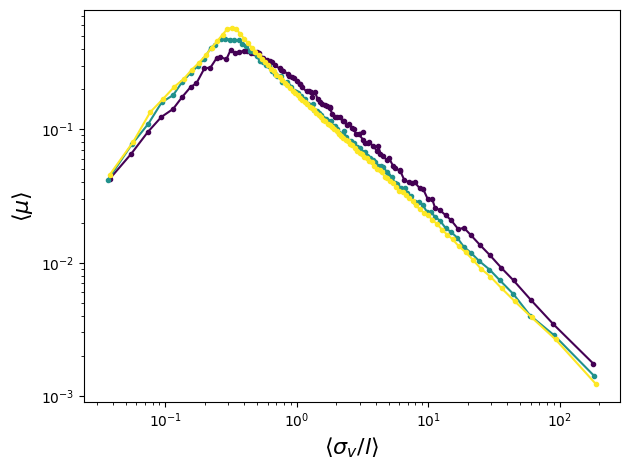

In [67]:
fig, ax = plt.subplots()

N_steps_norm = LogNorm(1, 10_000)
nv_norm = plt.Normalize(10, 100)
cmap = plt.cm.viridis

# nv = 20
# for data, name, el in zip([data_0_20, data_100_20, data_10000_20], ['0', '100', '10000'], [edge_length_thomson_0_20, edge_length_thomson_100_20, edge_length_thomson_10000_20]):
#     x_raw = 1 - data['a_rad'] / p_rad
#     x_unique = np.unique(x_raw)
#     a_rad_unique = np.unique(data['a_rad'])
#     idx = np.searchsorted(a_rad_unique, data['a_rad'])
#     el_raw = el[idx]
#     x_raw = el_raw / data['a_rad']
#     x_unique = el / a_rad_unique
#     metrics = {'mu_mean': ('k', r'$\langle \mu \rangle$')}
#     for key, (color, label) in metrics.items():
#         y_vals = data[key]
#         y_center = np.array([np.mean(y_vals[x_raw == xi]) for xi in x_unique])
#         y_err = np.array([np.std(y_vals[x_raw == xi]) for xi in x_unique])
#         ax.errorbar(1 / x_unique, y_center, yerr=y_err, color=cmap(N_steps_norm(float(name) + 1)), fmt='-o',
#                      markersize=3, capsize=2)

thomson_df = {
    'x_0': [],
    'y_0': [],
    'x_100': [],
    'y_100': [],
    'x_10000': [],
    'y_10000': [],
}

nv = 50
for data, name, el in zip([data_0_50, data_100_50, data_10000_50], ['0', '100', '10000'], [edge_length_thomson_0_50, edge_length_thomson_100_50, edge_length_thomson_10000_50]):
    x_raw = 1 - data['a_rad'] / p_rad
    x_unique = np.unique(x_raw)
    a_rad_unique = np.unique(data['a_rad'])
    idx = np.searchsorted(a_rad_unique, data['a_rad'])
    el_raw = el[idx]
    x_raw = el_raw / data['a_rad']
    x_unique = el / a_rad_unique
    metrics = {'mu_mean': ('k', r'$\langle \mu \rangle$')}
    for key, (color, label) in metrics.items():
        y_vals = data[key]
        y_center = np.array([np.mean(y_vals[x_raw == xi]) for xi in x_unique])
        y_err = np.array([np.std(y_vals[x_raw == xi]) for xi in x_unique])
        ax.errorbar(1 / x_unique, y_center, color=cmap(N_steps_norm(float(name) + 1)), fmt='-o',
                     markersize=3, capsize=2)
        thomson_df[f'x_{name}'] = 1 / x_unique
        thomson_df[f'y_{name}'] = y_center

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$\langle \sigma_v / l \rangle$', fontsize=16)
ax.set_ylabel(r'$\langle \mu \rangle$', fontsize=16)
fig.tight_layout()
# plt.savefig(f'figures-thomson/nv-{nv}-n_steps-{name}-friction-curves.png', dpi=600)
plt.show()

import pandas as pd
pd.DataFrame(thomson_df).to_csv('thomson_edge_length_data.csv', index=False)

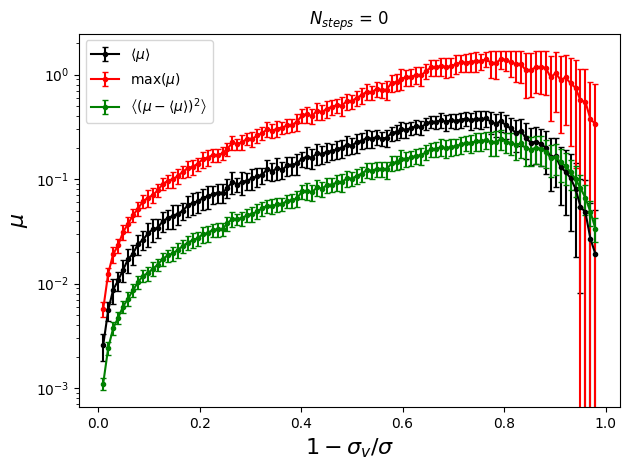

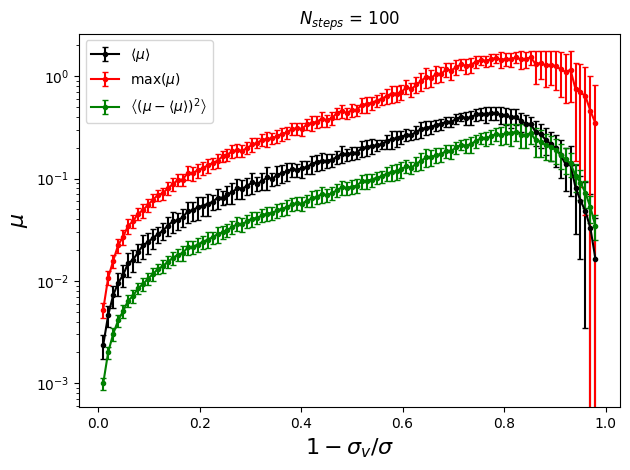

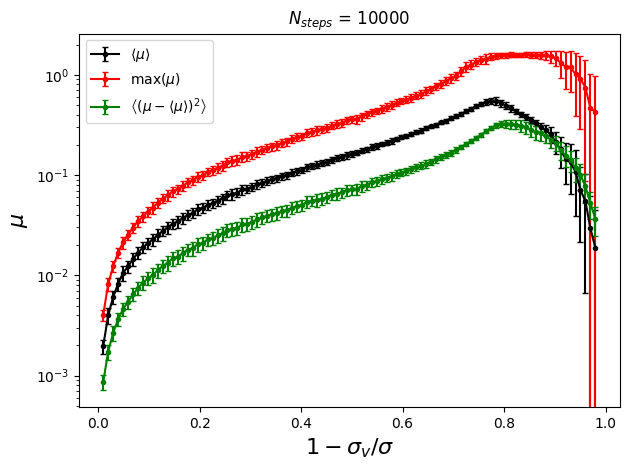

In [25]:
nv = 20
for data, name in zip([data_0_20, data_100_20, data_10000_20], ['0', '100', '10000']):
    x_raw = 1 - data['a_rad'] / p_rad
    x_unique = np.unique(x_raw)
    x_unique.sort()

    metrics = {'mu_mean': ('k', r'$\langle \mu \rangle$'),
               'mu_max': ('r', r'$\max(\mu)$'),
               'mu_std': ('g', r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$')}

    fig, ax = plt.subplots()
    for key, (color, label) in metrics.items():
        y_vals = data[key]
        y_center = np.array([np.mean(y_vals[x_raw == xi]) for xi in x_unique])
        y_err = np.array([np.std(y_vals[x_raw == xi]) for xi in x_unique])

        ax.errorbar(x_unique, y_center, yerr=y_err, color=color, fmt='-o',
                     markersize=3, capsize=2, label=label)

    ax.set_yscale('log')
    # ax.set_xscale('log')
    ax.legend()
    ax.set_xlabel(r'$1 - \sigma_v / \sigma$', fontsize=16)
    ax.set_ylabel(r'$\mu$', fontsize=16)
    ax.set_title(rf'$N_{{steps}}$ = {name}')
    fig.tight_layout()
    plt.savefig(f'figures-thomson/nv-{nv}-n_steps-{name}-friction-curves.png', dpi=600)
    plt.show()

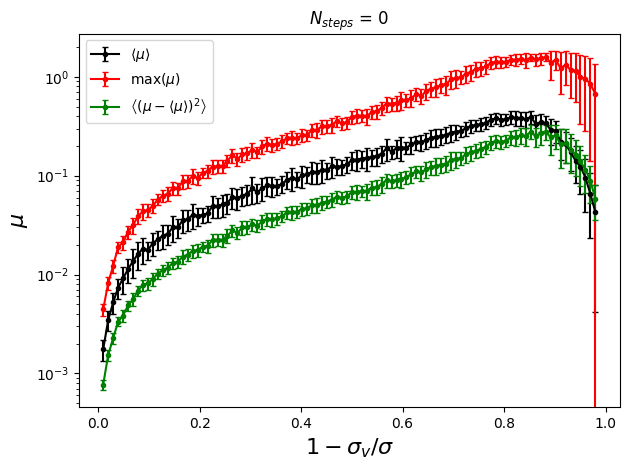

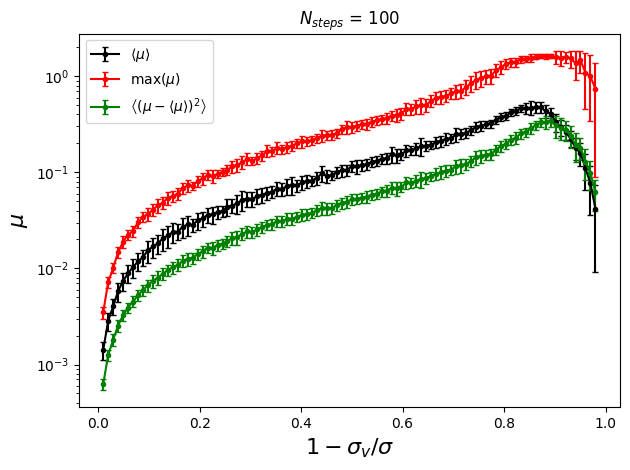

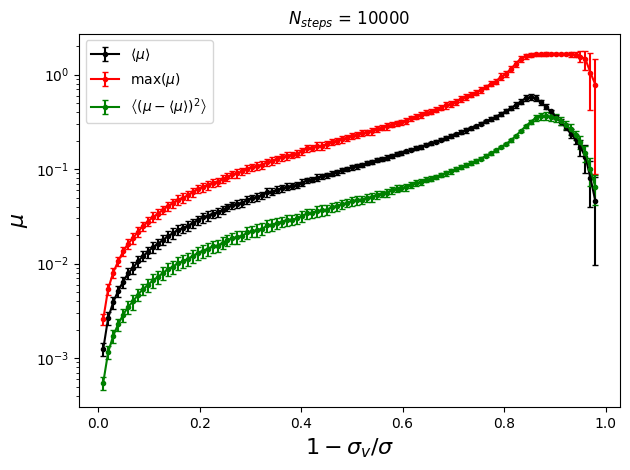

: 

In [ ]:
nv = 50
for data, name in zip([data_0_50, data_100_50, data_10000_50], ['0', '100', '10000']):
    x_raw = 1 - data['a_rad'] / p_rad
    x_unique = np.unique(x_raw)
    x_unique.sort()

    metrics = {'mu_mean': ('k', r'$\langle \mu \rangle$'),
               'mu_max': ('r', r'$\max(\mu)$'),
               'mu_std': ('g', r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$')}

    fig, ax = plt.subplots()
    for key, (color, label) in metrics.items():
        y_vals = data[key]
        y_center = np.array([np.mean(y_vals[x_raw == xi]) for xi in x_unique])
        y_err = np.array([np.std(y_vals[x_raw == xi]) for xi in x_unique])

        ax.errorbar(x_unique, y_center, yerr=y_err, color=color, fmt='-o',
                     markersize=3, capsize=2, label=label)

    ax.set_yscale('log')
    # ax.set_xscale('log')
    ax.legend()
    ax.set_xlabel(r'$1 - \sigma_v / \sigma$', fontsize=16)
    ax.set_ylabel(r'$\mu$', fontsize=16)
    ax.set_title(rf'$N_{{steps}}$ = {name}')
    fig.tight_layout()
    plt.savefig(f'figures-thomson/nv-{nv}-n_steps-{name}-friction-curves.png', dpi=600)
    plt.show()